# Marketing Funnel and Customer Retention Analysis

This notebook analyzes an Olist-style SQLite database with two main business questions:

1. **Acquisition:** Which marketing channels generate MQLs that convert into closed deals most effectively?
2. **Retention:** How often do customers return for a later purchase, and is repeat purchasing associated with first-order review score?

The notebook is designed to be reproducible: SQL is executed directly against SQLite and results are loaded into pandas.


## 1. Setup and database connection

Update `DB_PATH` if your database is stored somewhere else. The default assumes this notebook is inside a `notebooks/` folder and the database is inside `data/`.


In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

DB_PATH = "../sql/olist.db"  # <-- change if needed

connection = sqlite3.connect(DB_PATH)

pd.read_sql_query("""
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
      AND name NOT LIKE 'sqlite_%'
    ORDER BY name;
""", connection)


,name
0,closed_deals
1,customers
2,geolocation
3,marketing_qualified_leads
4,order_items
5,order_payments
6,order_reviews
7,orders
8,products
9,sellers


## 2. Marketing funnel analysis


### 2.1 Overall MQL-to-deal conversion

This establishes the baseline conversion rate for all marketing-qualified leads.


In [3]:
query = """
SELECT
    COUNT(DISTINCT m.mql_id) AS total_mqls,
    COUNT(DISTINCT d.mql_id) AS closed_deals,
    ROUND(
        100.0 * COUNT(DISTINCT d.mql_id)
        / COUNT(DISTINCT m.mql_id),
        2
    ) AS conversion_rate
FROM marketing_qualified_leads m
LEFT JOIN closed_deals d
    ON m.mql_id = d.mql_id;
"""

conversion = pd.read_sql_query(query, connection)
conversion


,total_mqls,closed_deals,conversion_rate
0,8000,842,10.53


### 2.2 Conversion by acquisition channel

We compare MQL volume, closed-deal volume, conversion efficiency, and each channel's share of closed deals. `NULL` origins are excluded from the channel-performance table, while `unknown` is retained because it is a distinct source category in the dataset.


In [4]:
query = """
WITH origin_stats AS (
    SELECT
        m.origin,
        COUNT(*) AS total_mqls,
        COUNT(d.mql_id) AS closed_deals,
        ROUND(
            100.0 * COUNT(d.mql_id) / COUNT(*),
            2
        ) AS conversion_rate
    FROM marketing_qualified_leads m
    LEFT JOIN closed_deals d
        ON m.mql_id = d.mql_id
    WHERE m.origin IS NOT NULL
    GROUP BY m.origin
)

SELECT
    origin,
    total_mqls,
    closed_deals,
    conversion_rate,
    ROUND(
        100.0 * closed_deals /
        (SELECT SUM(closed_deals) FROM origin_stats),
        2
    ) AS deal_share
FROM origin_stats
ORDER BY closed_deals DESC;
"""

origin_performance = pd.read_sql_query(query, connection)
origin_performance


,origin,total_mqls,closed_deals,conversion_rate,deal_share
0,organic_search,2296,271,11.80,32.73
1,paid_search,1586,195,12.30,23.55
2,unknown,1099,179,16.29,21.62
3,social,1350,75,5.56,9.06
4,direct_traffic,499,56,11.22,6.76
5,referral,284,24,8.45,2.90
6,email,493,15,3.04,1.81
7,display,118,6,5.08,0.72
8,other,150,4,2.67,0.48
9,other_publicities,65,3,4.62,0.36


### 2.3 Statistical comparison with the overall baseline

A simple two-sided z-test compares each origin's conversion rate with the overall observed rate. Treat these results as descriptive evidence rather than causal proof.


In [5]:
query = """
SELECT
    m.origin,
    COUNT(*) AS total_mqls,
    COUNT(d.mql_id) AS closed_deals
FROM marketing_qualified_leads m
LEFT JOIN closed_deals d
    ON m.mql_id = d.mql_id
WHERE m.origin IS NOT NULL
GROUP BY m.origin;
"""

origin_stats = pd.read_sql_query(query, connection)

overall_deals = origin_stats["closed_deals"].sum()
overall_mqls = origin_stats["total_mqls"].sum()
overall_rate = overall_deals / overall_mqls

results = []
for _, row in origin_stats.iterrows():
    p1 = row["closed_deals"] / row["total_mqls"]
    p0 = overall_rate
    se = (p0 * (1 - p0) / row["total_mqls"]) ** 0.5
    z = (p1 - p0) / se
    p_value = 2 * (1 - norm.cdf(abs(z)))

    results.append({
        "origin": row["origin"],
        "conversion_rate": round(p1 * 100, 2),
        "difference_from_overall": round((p1 - p0) * 100, 2),
        "z_score": round(z, 2),
        "p_value": round(p_value, 4)
    })

significance = pd.DataFrame(results).sort_values("p_value")
significance


,origin,conversion_rate,difference_from_overall,z_score,p_value
2,email,3.04,-7.39,-5.37,0.0000
8,social,5.56,-4.87,-5.86,0.0000
9,unknown,16.29,5.86,6.36,0.0000
4,other,2.67,-7.76,-3.11,0.0019
6,paid_search,12.30,1.87,2.43,0.0150
3,organic_search,11.80,1.37,2.16,0.0311
1,display,5.08,-5.34,-1.90,0.0575
5,other_publicities,4.62,-5.81,-1.53,0.1252
7,referral,8.45,-1.98,-1.09,0.2755
0,direct_traffic,11.22,0.79,0.58,0.5616


### 2.4 Final acquisition visualization: volume vs. conversion

Bubble size represents the number of closed deals. `unknown` is excluded from the final chart because it is not an actionable acquisition channel.


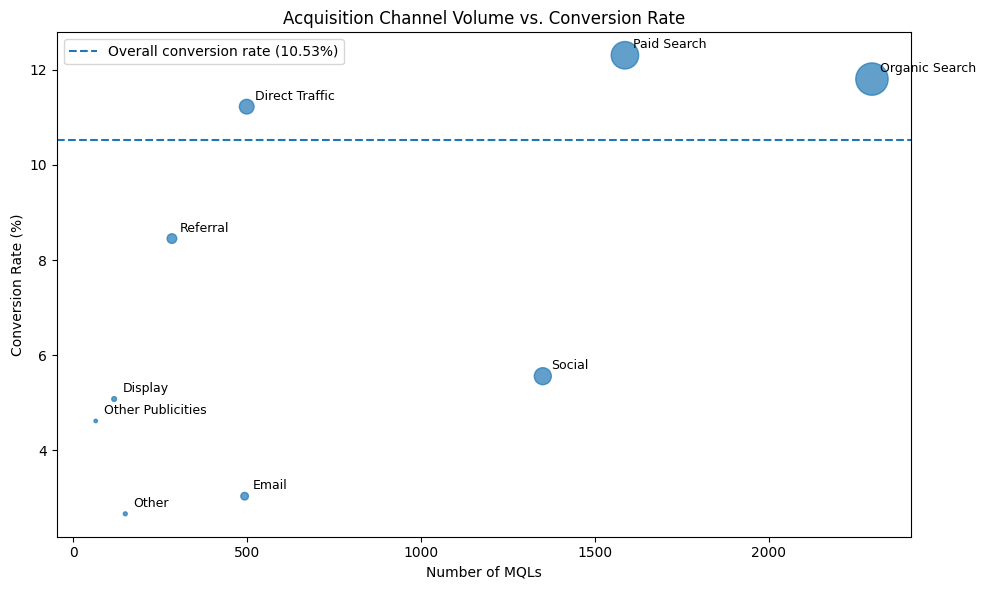

In [6]:
plot_data = origin_performance[
    origin_performance["origin"] != "unknown"
].copy()

plot_data["channel"] = (
    plot_data["origin"]
    .str.replace("_", " ", regex=False)
    .str.title()
)

plt.figure(figsize=(10, 6))
plt.scatter(
    plot_data["total_mqls"],
    plot_data["conversion_rate"],
    s=plot_data["closed_deals"] * 2,
    alpha=0.7
)

plt.axhline(
    y=10.53,
    linestyle="--",
    label="Overall conversion rate (10.53%)"
)

for _, row in plot_data.iterrows():
    plt.annotate(
        row["channel"],
        (row["total_mqls"], row["conversion_rate"]),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("Number of MQLs")
plt.ylabel("Conversion Rate (%)")
plt.title("Acquisition Channel Volume vs. Conversion Rate")
plt.legend()
plt.tight_layout()
plt.show()


### 2.5 Conversion timing and data-quality check

We calculate time from MQL first contact to won date. One record has a slightly negative duration, so it is excluded from timing-only analyses but retained in the source data.


In [7]:
query = """
SELECT
    m.mql_id,
    m.first_contact_date,
    d.won_date,
    julianday(d.won_date) - julianday(m.first_contact_date) AS days_to_conversion
FROM marketing_qualified_leads m
JOIN closed_deals d
    ON m.mql_id = d.mql_id
WHERE julianday(d.won_date) >= julianday(m.first_contact_date);
"""

conversion_time = pd.read_sql_query(query, connection)
conversion_time["days_to_conversion"].describe()


count    841.000000
mean      49.160558
std       75.359739
min        0.083333
25%        5.859954
50%       14.722164
75%       55.125000
max      427.551817
Name: days_to_conversion, dtype: float64

### 2.6 60-day conversion by MQL cohort month

A standardized 60-day window avoids comparing leads with different amounts of follow-up time.


In [8]:
query = """
WITH mql_cohorts AS (
    SELECT
        m.mql_id,
        DATE(m.first_contact_date, 'start of month') AS cohort_month,
        m.first_contact_date,
        MIN(d.won_date) AS won_date
    FROM marketing_qualified_leads m
    LEFT JOIN closed_deals d
        ON m.mql_id = d.mql_id
    GROUP BY
        m.mql_id,
        cohort_month,
        m.first_contact_date
),

eligible_mqls AS (
    SELECT *
    FROM mql_cohorts
    WHERE DATE(first_contact_date, '+60 days') <= (
        SELECT DATE(MAX(won_date))
        FROM closed_deals
    )
)

SELECT
    cohort_month,
    COUNT(*) AS total_mqls,
    COUNT(
        CASE
            WHEN won_date IS NOT NULL
             AND julianday(won_date) - julianday(first_contact_date) BETWEEN 0 AND 60
            THEN 1
        END
    ) AS converted_within_60_days,
    ROUND(
        100.0 *
        COUNT(
            CASE
                WHEN won_date IS NOT NULL
                 AND julianday(won_date) - julianday(first_contact_date) BETWEEN 0 AND 60
                THEN 1
            END
        ) / COUNT(*),
        2
    ) AS conversion_rate_60d
FROM eligible_mqls
GROUP BY cohort_month
ORDER BY cohort_month;
"""

monthly_conversion = pd.read_sql_query(query, connection)
monthly_conversion


,cohort_month,total_mqls,converted_within_60_days,conversion_rate_60d
0,2017-06-01,4,0,0.00
1,2017-07-01,239,0,0.00
2,2017-08-01,386,0,0.00
3,2017-09-01,312,0,0.00
4,2017-10-01,416,0,0.00
5,2017-11-01,445,4,0.90
6,2017-12-01,200,6,3.00
7,2018-01-01,1141,117,10.25
8,2018-02-01,1028,119,11.58
9,2018-03-01,1174,134,11.41


### 2.7 Final acquisition trend chart

The 2018 cohorts are used for the final comparison because the earlier period is affected by the late start of observed closed-deal activity.


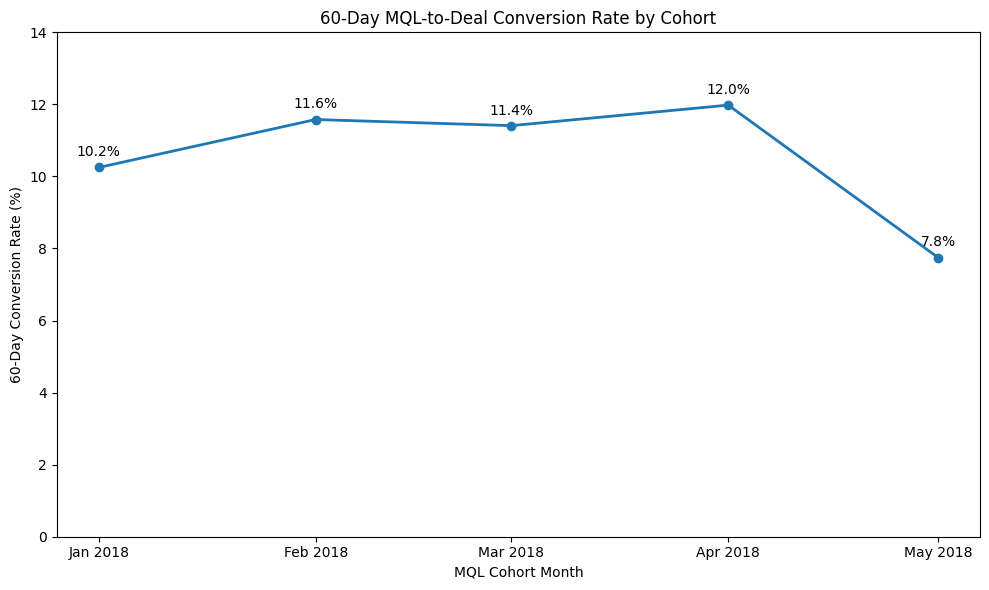

In [9]:
monthly_conversion["cohort_month"] = pd.to_datetime(
    monthly_conversion["cohort_month"]
)

conversion_2018 = monthly_conversion[
    monthly_conversion["cohort_month"] >= "2018-01-01"
].copy()

plt.figure(figsize=(10, 6))
plt.plot(
    conversion_2018["cohort_month"],
    conversion_2018["conversion_rate_60d"],
    marker="o",
    linewidth=2
)

for _, row in conversion_2018.iterrows():
    plt.annotate(
        f'{row["conversion_rate_60d"]:.1f}%',
        (row["cohort_month"], row["conversion_rate_60d"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.xlabel("MQL Cohort Month")
plt.ylabel("60-Day Conversion Rate (%)")
plt.title("60-Day MQL-to-Deal Conversion Rate by Cohort")
plt.xticks(
    conversion_2018["cohort_month"],
    conversion_2018["cohort_month"].dt.strftime("%b %Y")
)
plt.ylim(0, 14)
plt.tight_layout()
plt.show()


## 3. Customer retention analysis


### 3.1 Orders per unique customer

`customer_unique_id` is used rather than `customer_id` because the latter identifies order-specific customer records.


In [10]:
query = """
SELECT
    c.customer_unique_id,
    COUNT(DISTINCT o.order_id) AS order_count
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
GROUP BY c.customer_unique_id;
"""

customer_orders = pd.read_sql_query(query, connection)

print(customer_orders["order_count"].describe())
print()
print(customer_orders["order_count"].value_counts().sort_index())


count    96096.000000
mean         1.034809
std          0.214384
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: order_count, dtype: float64

order_count
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64


### 3.2 Genuine repeat-purchase rate

Orders with exactly the same purchase timestamp are treated as part of the same initial purchasing event rather than as customer retention. A repeat customer must have a later purchase timestamp.


In [11]:
query = """
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        o.order_id,
        o.order_purchase_timestamp
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
),

first_orders AS (
    SELECT
        customer_unique_id,
        MIN(order_purchase_timestamp) AS first_order
    FROM customer_orders
    GROUP BY customer_unique_id
)

SELECT
    f.customer_unique_id,
    f.first_order,
    COUNT(DISTINCT CASE
        WHEN co.order_purchase_timestamp > f.first_order
        THEN co.order_id
    END) AS subsequent_orders
FROM first_orders f
JOIN customer_orders co
    ON f.customer_unique_id = co.customer_unique_id
GROUP BY
    f.customer_unique_id,
    f.first_order;
"""

customer_retention = pd.read_sql_query(query, connection)

repeat_customers = (customer_retention["subsequent_orders"] > 0).sum()
total_customers = len(customer_retention)
repeat_rate = 100 * repeat_customers / total_customers

print("Total customers:", total_customers)
print("Repeat customers:", repeat_customers)
print("Repeat purchase rate:", round(repeat_rate, 2), "%")


Total customers: 96096
Repeat customers: 2740
Repeat purchase rate: 2.85 %


### 3.3 Time to genuine repeat purchase


In [12]:
query = """
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        o.order_purchase_timestamp
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
),

first_orders AS (
    SELECT
        customer_unique_id,
        MIN(order_purchase_timestamp) AS first_order
    FROM customer_orders
    GROUP BY customer_unique_id
),

repeat_orders AS (
    SELECT
        f.customer_unique_id,
        f.first_order,
        MIN(co.order_purchase_timestamp) AS second_purchase
    FROM first_orders f
    JOIN customer_orders co
        ON f.customer_unique_id = co.customer_unique_id
       AND co.order_purchase_timestamp > f.first_order
    GROUP BY
        f.customer_unique_id,
        f.first_order
)

SELECT
    customer_unique_id,
    first_order,
    second_purchase,
    julianday(second_purchase) - julianday(first_order) AS days_to_repeat
FROM repeat_orders;
"""

repeat_timing_clean = pd.read_sql_query(query, connection)

repeat_timing_clean["days_to_repeat"].describe(
    percentiles=[.25, .5, .75, .9, .95]
)


count    2740.000000
mean       88.471718
std       112.486355
min         0.000012
25%         1.903779
50%        39.093600
75%       138.291739
90%       260.383878
95%       332.831969
max       608.978912
Name: days_to_repeat, dtype: float64

### 3.4 90-day repeat-purchase cohorts

A fixed 90-day observation window makes cohorts comparable and avoids penalizing customers who entered near the end of the dataset.


In [13]:
query = """
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        o.order_purchase_timestamp
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
),

first_orders AS (
    SELECT
        customer_unique_id,
        MIN(order_purchase_timestamp) AS first_order
    FROM customer_orders
    GROUP BY customer_unique_id
),

customer_retention AS (
    SELECT
        f.customer_unique_id,
        f.first_order,
        MIN(co.order_purchase_timestamp) AS repeat_order
    FROM first_orders f
    LEFT JOIN customer_orders co
        ON f.customer_unique_id = co.customer_unique_id
       AND co.order_purchase_timestamp > f.first_order
    GROUP BY
        f.customer_unique_id,
        f.first_order
),

eligible AS (
    SELECT *
    FROM customer_retention
    WHERE DATE(first_order, '+90 days') <= (
        SELECT DATE(MAX(order_purchase_timestamp))
        FROM orders
    )
)

SELECT
    DATE(first_order, 'start of month') AS cohort_month,
    COUNT(*) AS customers,
    COUNT(
        CASE
            WHEN repeat_order IS NOT NULL
             AND julianday(repeat_order) - julianday(first_order) BETWEEN 0 AND 90
            THEN 1
        END
    ) AS repeat_customers_90d,
    ROUND(
        100.0 *
        COUNT(
            CASE
                WHEN repeat_order IS NOT NULL
                 AND julianday(repeat_order) - julianday(first_order) BETWEEN 0 AND 90
                THEN 1
            END
        ) / COUNT(*),
        2
    ) AS repeat_rate_90d
FROM eligible
GROUP BY cohort_month
ORDER BY cohort_month;
"""

retention_cohorts = pd.read_sql_query(query, connection)
retention_cohorts


,cohort_month,customers,repeat_customers_90d,repeat_rate_90d
0,2016-09-01,4,0,0.00
1,2016-10-01,321,3,0.93
2,2016-12-01,1,1,100.00
3,2017-01-01,764,24,3.14
4,2017-02-01,1752,28,1.60
5,2017-03-01,2636,61,2.31
6,2017-04-01,2352,44,1.87
7,2017-05-01,3596,93,2.59
8,2017-06-01,3139,84,2.68
9,2017-07-01,3894,88,2.26


### 3.5 Final retention visualization


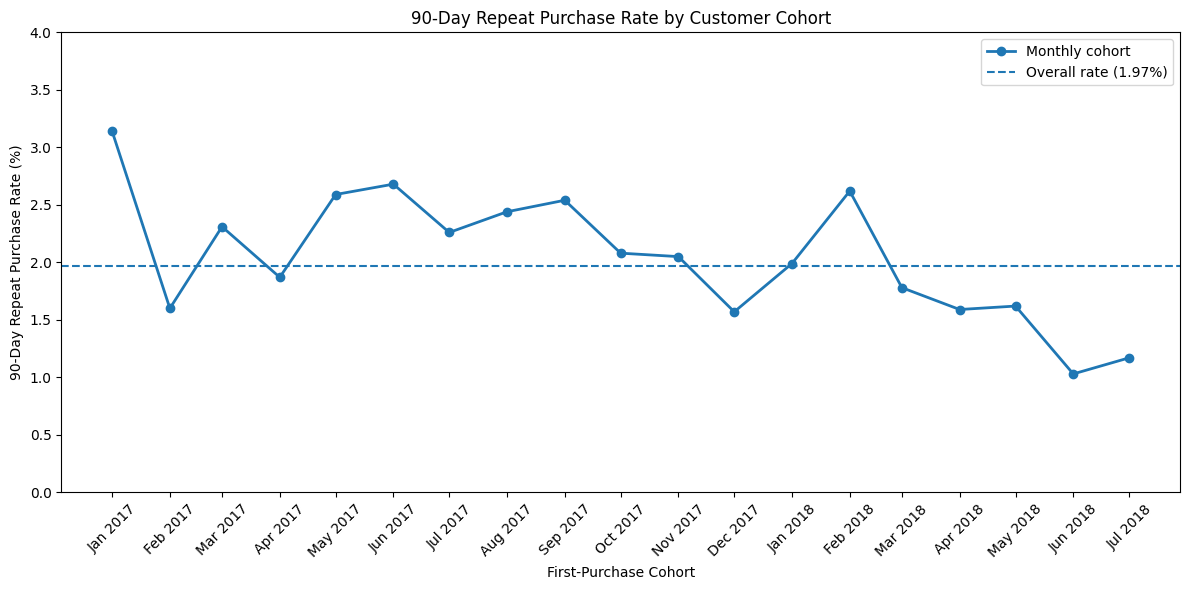

In [14]:
retention_cohorts["cohort_month"] = pd.to_datetime(
    retention_cohorts["cohort_month"]
)

retention_plot = retention_cohorts[
    retention_cohorts["cohort_month"] >= "2017-01-01"
].copy()

overall_repeat_rate = (
    retention_plot["repeat_customers_90d"].sum()
    / retention_plot["customers"].sum()
    * 100
)

plt.figure(figsize=(12, 6))
plt.plot(
    retention_plot["cohort_month"],
    retention_plot["repeat_rate_90d"],
    marker="o",
    linewidth=2,
    label="Monthly cohort"
)

plt.axhline(
    y=overall_repeat_rate,
    linestyle="--",
    label=f"Overall rate ({overall_repeat_rate:.2f}%)"
)

plt.xlabel("First-Purchase Cohort")
plt.ylabel("90-Day Repeat Purchase Rate (%)")
plt.title("90-Day Repeat Purchase Rate by Customer Cohort")
plt.xticks(
    retention_plot["cohort_month"],
    retention_plot["cohort_month"].dt.strftime("%b %Y"),
    rotation=45
)
plt.ylim(0, 4)
plt.legend()
plt.tight_layout()
plt.show()


### 3.6 First-order review score vs. 90-day repeat purchasing

Orders with multiple review rows are reduced to the average review score for that order. The result should be interpreted as an association, not a causal effect.


In [15]:
query = """
WITH review_scores AS (
    SELECT
        order_id,
        AVG(review_score) AS review_score
    FROM order_reviews
    GROUP BY order_id
),

customer_orders AS (
    SELECT
        c.customer_unique_id,
        o.order_id,
        o.order_purchase_timestamp
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
),

first_purchase AS (
    SELECT
        customer_unique_id,
        MIN(order_purchase_timestamp) AS first_purchase_time
    FROM customer_orders
    GROUP BY customer_unique_id
),

first_purchase_orders AS (
    SELECT
        f.customer_unique_id,
        f.first_purchase_time,
        AVG(r.review_score) AS first_review_score
    FROM first_purchase f
    JOIN customer_orders co
        ON f.customer_unique_id = co.customer_unique_id
       AND f.first_purchase_time = co.order_purchase_timestamp
    LEFT JOIN review_scores r
        ON co.order_id = r.order_id
    GROUP BY
        f.customer_unique_id,
        f.first_purchase_time
),

retention AS (
    SELECT
        f.customer_unique_id,
        f.first_purchase_time,
        f.first_review_score,
        MIN(co.order_purchase_timestamp) AS repeat_purchase
    FROM first_purchase_orders f
    LEFT JOIN customer_orders co
        ON f.customer_unique_id = co.customer_unique_id
       AND co.order_purchase_timestamp > f.first_purchase_time
    GROUP BY
        f.customer_unique_id,
        f.first_purchase_time,
        f.first_review_score
),

eligible AS (
    SELECT *
    FROM retention
    WHERE DATE(first_purchase_time, '+90 days') <= (
        SELECT DATE(MAX(order_purchase_timestamp))
        FROM orders
    )
    AND first_review_score IS NOT NULL
)

SELECT
    ROUND(first_review_score, 0) AS review_score,
    COUNT(*) AS customers,
    COUNT(
        CASE
            WHEN repeat_purchase IS NOT NULL
             AND julianday(repeat_purchase) - julianday(first_purchase_time) BETWEEN 0 AND 90
            THEN 1
        END
    ) AS repeat_customers_90d,
    ROUND(
        100.0 *
        COUNT(
            CASE
                WHEN repeat_purchase IS NOT NULL
                 AND julianday(repeat_purchase) - julianday(first_purchase_time) BETWEEN 0 AND 90
                THEN 1
            END
        ) / COUNT(*),
        2
    ) AS repeat_rate_90d
FROM eligible
GROUP BY ROUND(first_review_score, 0)
ORDER BY review_score;
"""

review_retention = pd.read_sql_query(query, connection)
review_retention


,review_score,customers,repeat_customers_90d,repeat_rate_90d
0,1.0,10214,194,1.90
1,2.0,2797,51,1.82
2,3.0,7264,149,2.05
3,4.0,16785,298,1.78
4,5.0,49259,1001,2.03


## 4. Key findings

- Overall MQL-to-deal conversion is about **10.53%**.
- Organic and paid search combine substantial lead volume with above-average conversion, while social and email underperform the overall baseline.
- The 60-day MQL conversion rate is relatively stable in early 2018 before falling sharply in May; the decline appears across several acquisition channels and is not explained solely by channel mix.
- Only about **2.85%** of customers make a genuinely later purchase in the observed data once same-timestamp orders are excluded from the retention definition.
- Standardized 90-day repeat-purchase rates remain low across cohorts, generally around **1–3%**.
- First-order review score shows little apparent association with 90-day repeat purchasing.

## 5. Recommendations

- Prioritize investigation of **paid and organic search** as high-performing acquisition channels.
- Audit **social and email** targeting and lead-qualification processes before investing in more lead volume from those channels.
- Investigate the broad May 2018 conversion decline as an operational or funnel-quality issue, because it affects multiple channels.
- Treat retention as a separate strategic problem: customer satisfaction alone does not appear to explain the low repeat-purchase rate.

## 6. Limitations and data-quality notes

- `unknown` acquisition origin is retained in descriptive results but should not be treated as an actionable channel.
- One MQL had a won date slightly before first contact and was excluded from conversion-time analysis only.
- Multiple orders can share the exact same customer purchase timestamp; these are treated as one purchasing event for retention purposes.
- Some orders contain multiple reviews; their review scores are averaged when analyzing first-order satisfaction.
- The analysis is observational and does not establish causality.


## 7. Close the database connection


In [16]:
connection.close()
